<style>
/* Simple, readable notebook styling */
.rendered_html, .jp-Notebook, body {
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif;
  font-size: 16px;
  line-height: 1.6;
}
.rendered_html h1, .rendered_html h2, .rendered_html h3 { line-height: 1.25; }
.rendered_html code { font-size: 0.95em; }
</style>

# Anomaly Detection: Credit Card Fraud


Fraud is rare, which makes **standard supervised learning** tricky: the model can look “accurate” while still missing fraud.

## Supervised vs. anomaly detection

**Supervised learning**
- Needs labeled examples of both *normal* and *fraud*.
- Imbalanced labels (fraud is a tiny fraction) can bias the model toward predicting “normal”.

**Anomaly detection**
- Learns what “normal” looks like and flags **unusual** transactions as suspicious.
- Works even when you have very few fraud examples.

## Why anomaly detection is useful for fraud
- **Rare events:** designed for cases where anomalies are uncommon.
- **Adapts to new patterns:** can catch new fraud behaviors by detecting “out of pattern” activity.
- **Less labeling effort:** doesn’t require many fraud labels.

## Algorithms covered in this notebook
- Isolation Forest
- One-Class SVM
- Local Outlier Factor (LOF)
- DBSCAN
- Autoencoders


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout  
from tensorflow.keras.regularizers import l2 

palette = ['#00777F', '#5BABF5', '#AADEFE', '#EAAC9F', '#8AA0AF']
sns.set_theme(context='notebook', palette=palette, style='darkgrid')

# Suppress the FutureWarning
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 284807 rows and 31 columns.


In [5]:
df.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

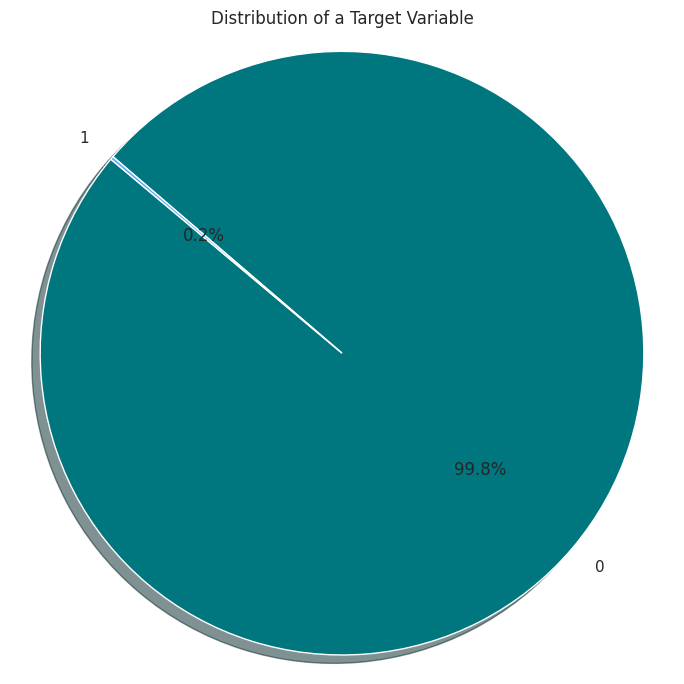

In [6]:
# Count the occurrences of each category
status_counts = df.Class.value_counts()

# Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=palette, shadow=True)

plt.title('Distribution of a Target Variable')
plt.axis('equal')  # Equal aspect ratio ensures that the pie is drawn as a circle.

# Display the chart
plt.tight_layout()
plt.show()

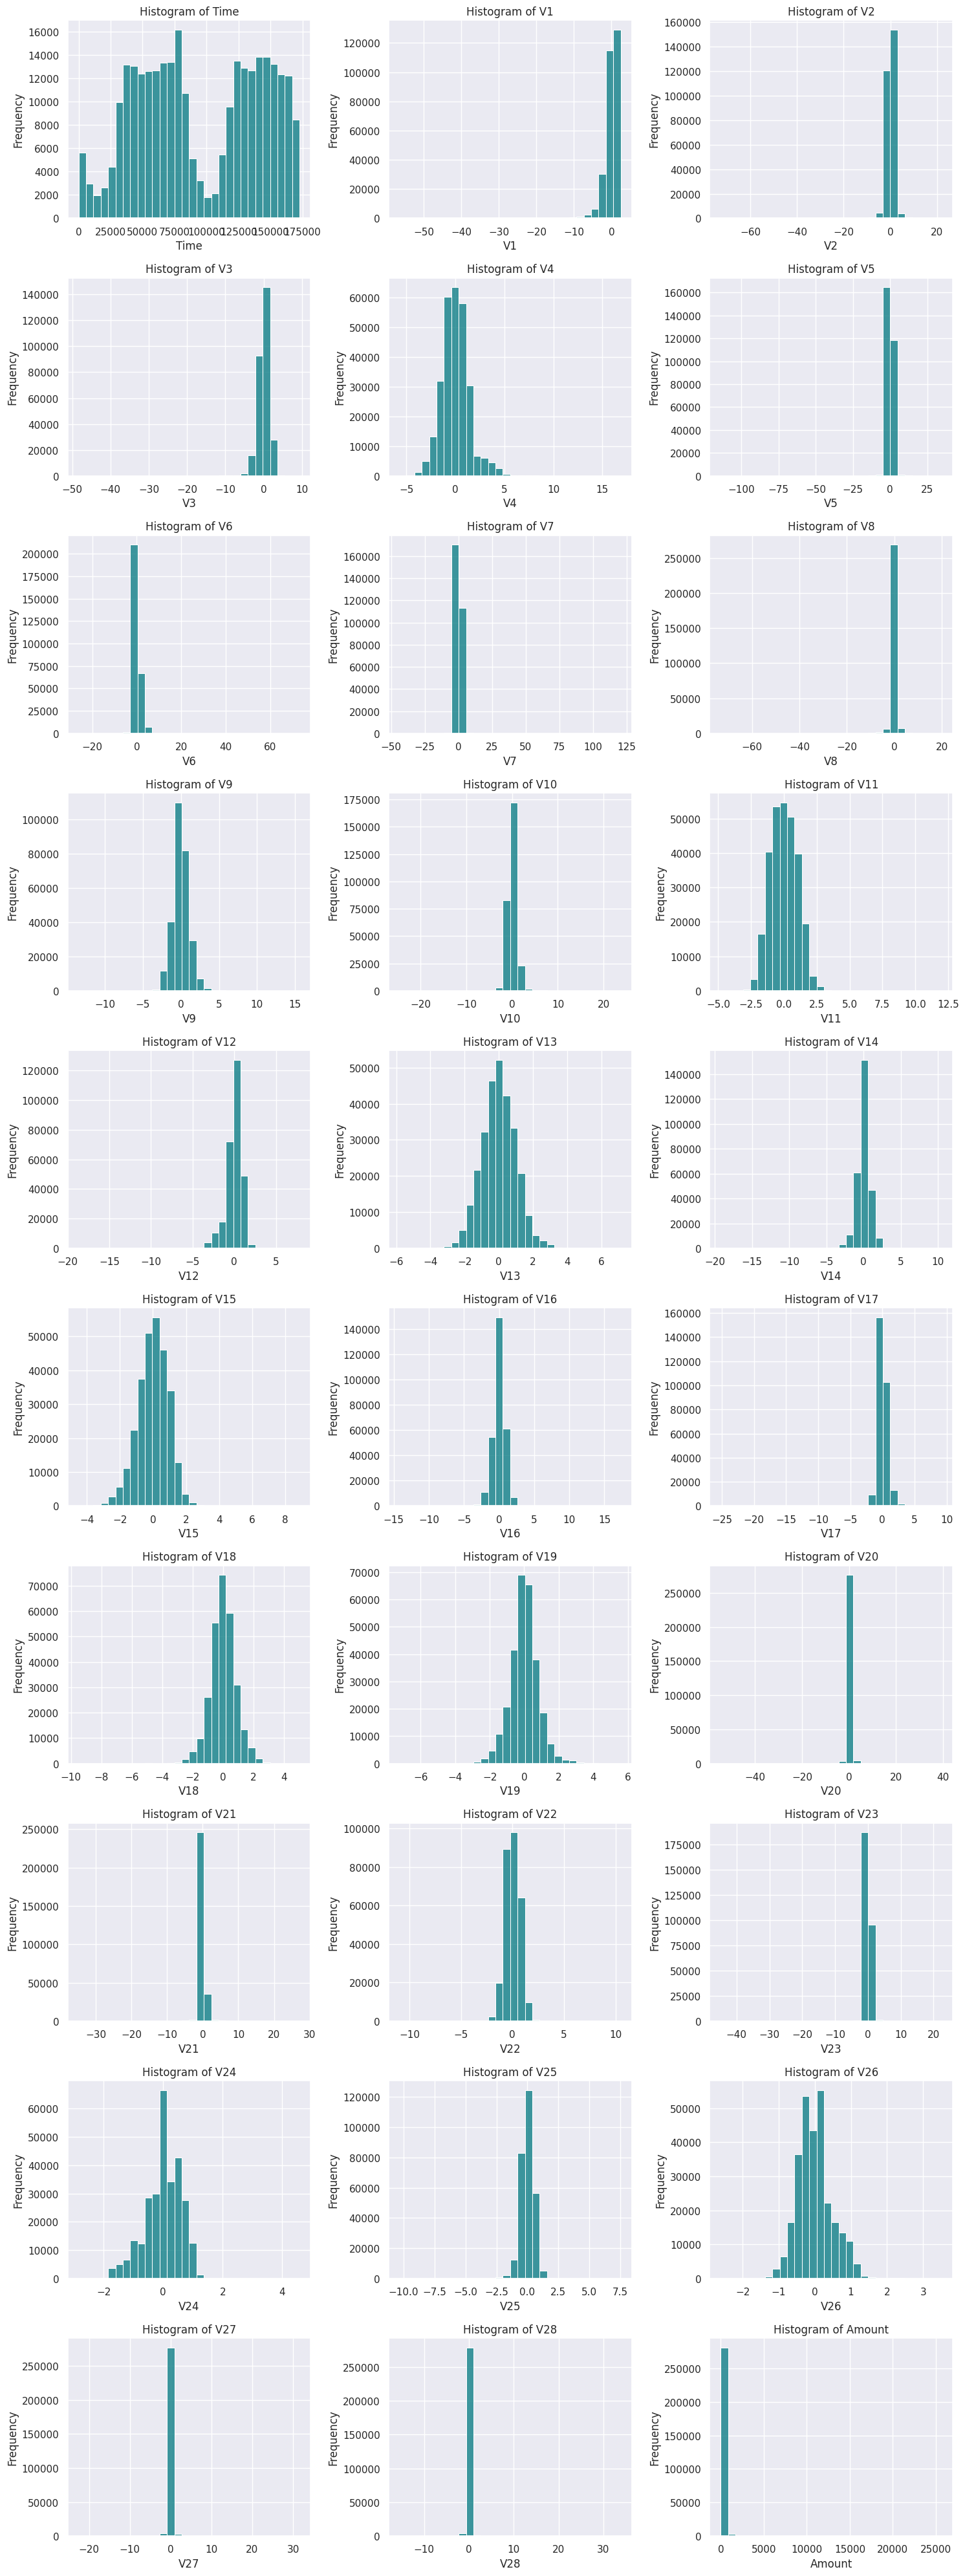

In [7]:
# Feature names
features = df.columns[:-1]

# Set up the figure; 10 rows (10*3=30 subplots), adjust as needed
fig, axes = plt.subplots(10, 3, figsize=(15, 40))  # Adjust rows to fit all features

# Flatten axes array to loop through easily
axes = axes.flatten()

# Plot each feature in a separate subplot
for i, feature in enumerate(features):
    sns.histplot(df[feature], ax=axes[i], kde=False, bins=30)
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots if features < 30
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Many anomaly-detection methods behave better when:
- features are on a similar scale, and/or
- the data is closer to a **Gaussian (normal) distribution**.

If features are highly skewed or have very different scales, algorithms may:
- flag too many normal points as anomalies (**false positives**), or
- miss true anomalies (**false negatives**).

### What we’ll do here
1. Inspect feature distributions (histograms).
2. Apply simple transformations (e.g., log/robust scaling) where needed.
3. Re-check distributions after transformation.


In [8]:
# Create a copy of the DataFrame to avoid changing the original
df_transformed = df.copy()

# Function to handle log transformation for skewed data
def log_transform_skewed(column):
    # For positive and zero values (log1p avoids log(0) errors)
    transformed = np.where(column >= 0, np.log1p(column), -np.log1p(-column))
    return transformed

# Compute skewness before transformation
skewness_before = df.skew()

# Apply transformation to skewed columns
for col in features:
    if abs(df[col].skew()) > 0.75:  # Threshold for skewness
        df_transformed[col] = log_transform_skewed(df[col])

# Compute skewness after transformation
skewness_after = df_transformed.skew()

# Compare skewness before and after
skewness_comparison = pd.DataFrame({
    'Skewness Before': skewness_before,
    'Skewness After': skewness_after
})

# Print the comparison
skewness_comparison

/opt/conda/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/conda/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Skewness Before,Skewness After
Time,-0.035568,-0.035568
V1,-3.280667,-0.364893
V2,-4.624866,-0.310128
V3,-2.240155,-0.315192
V4,0.676292,0.676292
V5,-2.425901,0.139077
V6,1.826581,0.804345
V7,2.553907,-0.112666
V8,-8.521944,-0.912642
V9,0.554680,0.554680


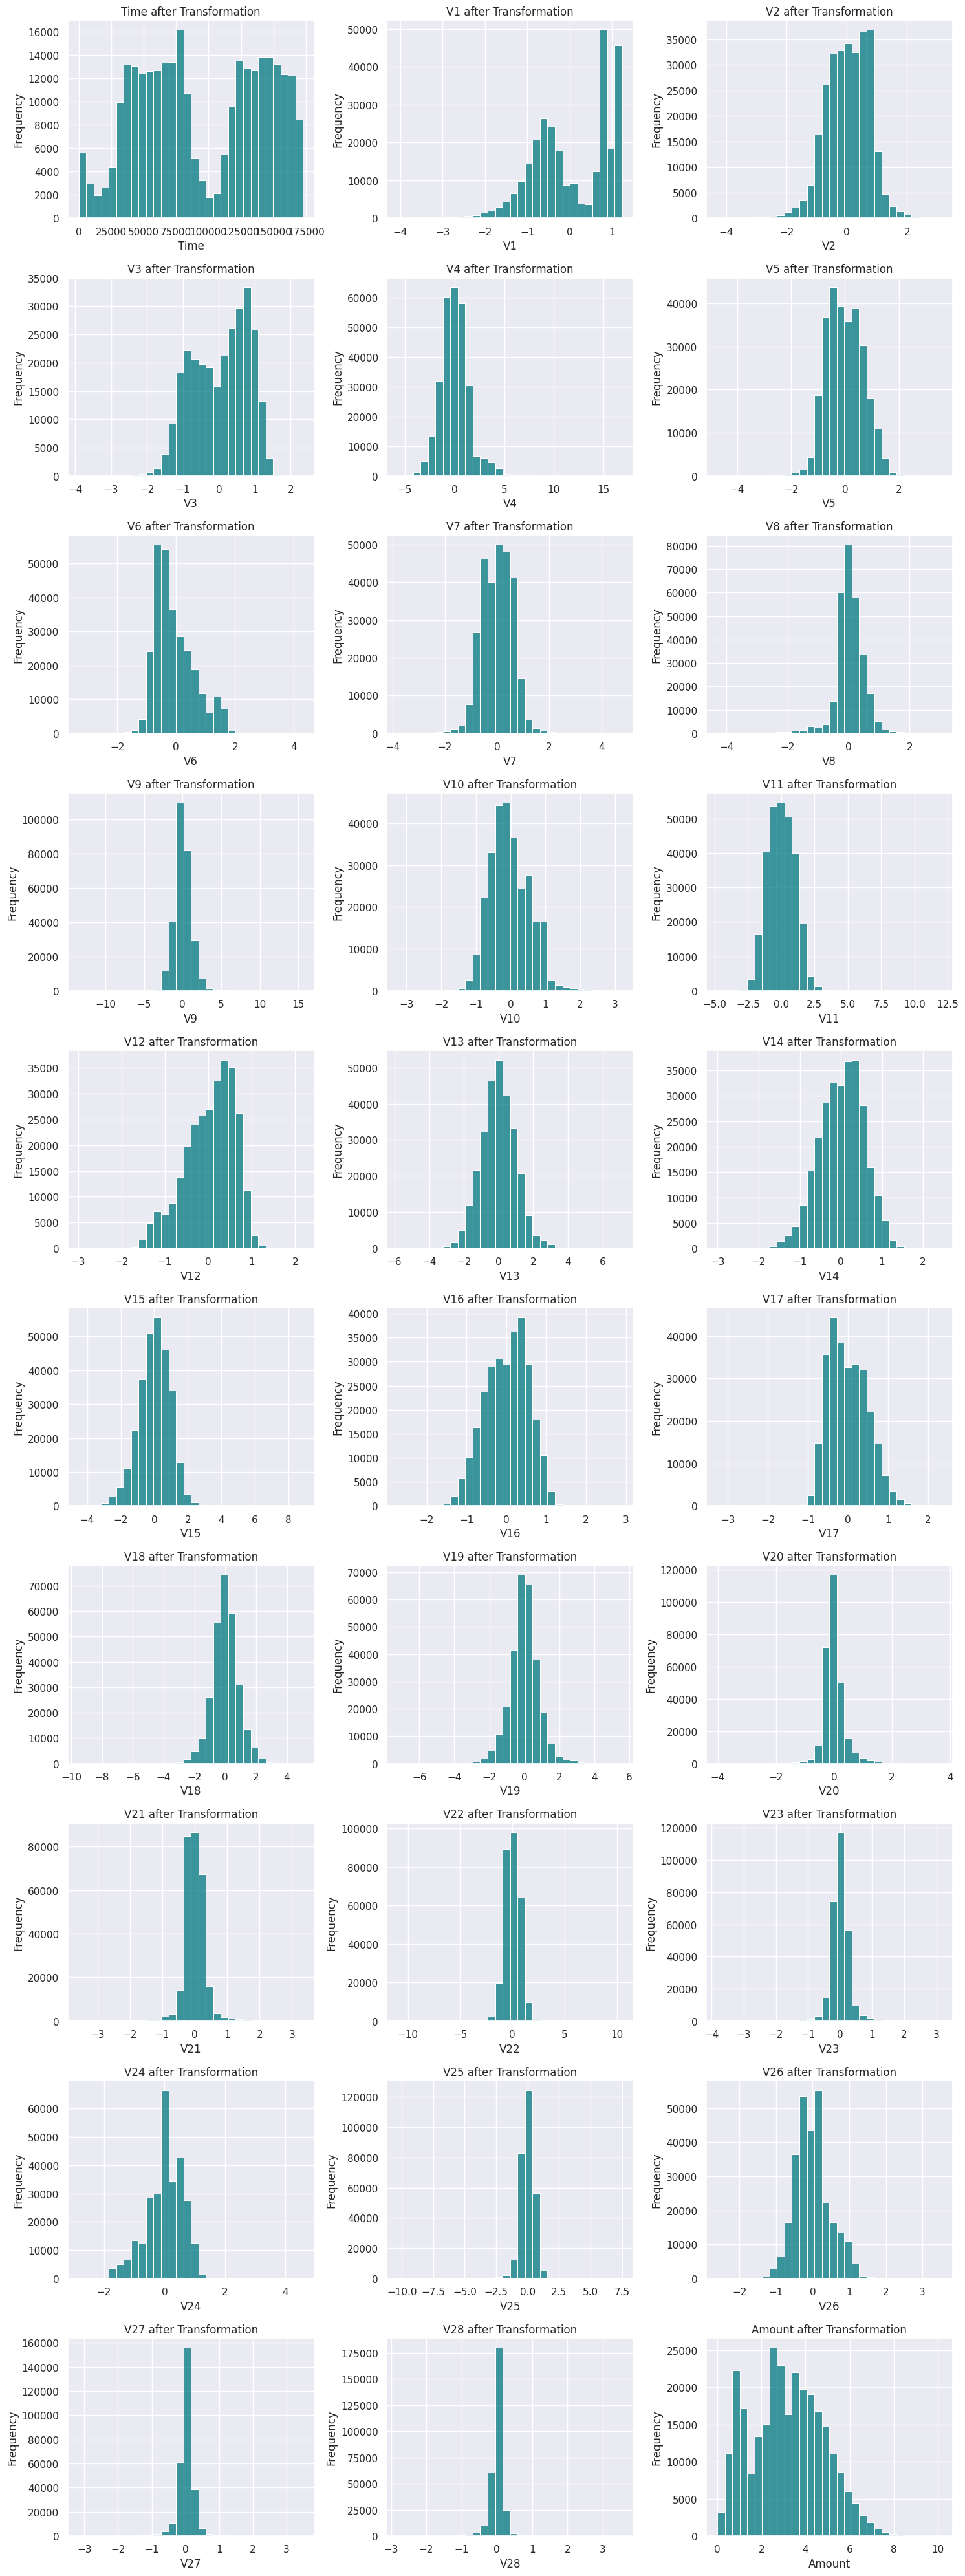

In [9]:
# Set up the figure; 10 rows (10*3=30 subplots), adjust as needed
fig, axes = plt.subplots(10, 3, figsize=(15, 40))  # Adjust rows to fit all features

# Flatten axes array to loop through easily
axes = axes.flatten()

# Plot each feature in a separate subplot
for i, feature in enumerate(features):
    sns.histplot(df_transformed[feature], ax=axes[i], kde=False, bins=30)
    axes[i].set_title(f'{feature} after Transformation')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots if features < 30
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [10]:
# Separate features and target
X = df_transformed[features]
y = df_transformed.Class

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Isolation Forest (unsupervised)**

- Randomly splits data using random features and thresholds.
- **Anomalies** tend to be isolated in fewer splits → shorter path length.
- Good for large datasets and fast scoring.

Trade-off: because it relies on random splits, it may miss very complex anomaly shapes.


In [11]:
# Initialize the Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=101)   # high contamination to catch more fraud transactions

# Fit the model and predict (returns -1 for anomalies and 1 for normal data)
iso_preds = iso_forest.fit_predict(X_scaled)

# Convert -1 (anomalies) to 1 (fraud) and 1 (normal) to 0 (non-fraud)
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

# Evaluate the results
print(classification_report(y, iso_preds))
roc_auc = roc_auc_score(y, iso_preds)
print("ROC AUC Score: ", roc_auc)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.85      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.90      0.52    284807
weighted avg       1.00      0.95      0.97    284807

ROC AUC Score:  0.9015054619225298


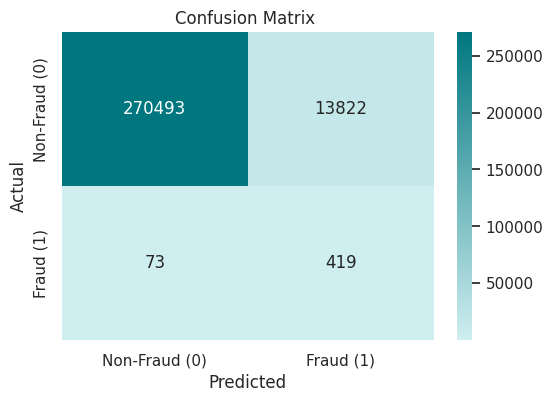

In [12]:
# Custom color palette
colors = ['#CFEEF0', '#00777F']
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Plot the confusion matrix
cm = confusion_matrix(y, iso_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

**One-Class SVM (unsupervised)**

- Learns a boundary around “normal” data.
- Anything outside the boundary is flagged as an anomaly.

Trade-off: can be slow on large datasets and sensitive to parameter choices (e.g., `nu`, kernel).


In [13]:
# Initialize One-Class SVM
oc_svm = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.05)

# Fit the model and predict (returns -1 for anomalies and 1 for normal data)
svm_preds = oc_svm.fit_predict(X_scaled)

# Convert -1 (anomalies) to 1 (fraud) and 1 (normal) to 0 (non-fraud)
svm_preds = [1 if x == -1 else 0 for x in svm_preds]

# Evaluate the results
print(classification_report(y, svm_preds))
roc_auc = roc_auc_score(y, svm_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix:")

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.03      0.86      0.06       492

    accuracy                           0.95    284807
   macro avg       0.51      0.90      0.52    284807
weighted avg       1.00      0.95      0.97    284807

ROC AUC Score:  0.9035432580861518
Confusion Matrix:


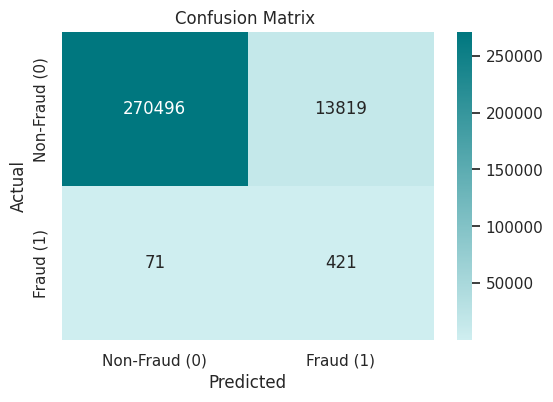

In [14]:
# Plot the confusion matrix
cm = confusion_matrix(y, svm_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

**Local Outlier Factor (LOF)**

- Compares the local density of a point to the density of its neighbors.
- A point with much lower density than its neighbors is treated as an outlier.

Trade-off: results depend on the `n_neighbors` choice and can be sensitive to noisy data.


In [15]:
# Initialize Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.05)

# Predict (returns -1 for anomalies and 1 for normal data)
lof_preds = lof.fit_predict(X_scaled)

# Convert -1 (anomalies) to 1 (fraud) and 1 (normal) to 0 (non-fraud)
lof_preds = [1 if x == -1 else 0 for x in lof_preds]

# Evaluate the results
print(classification_report(y, lof_preds))
roc_auc = roc_auc_score(y, lof_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix:")
print(confusion_matrix(y, lof_preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284315
           1       0.00      0.11      0.01       492

    accuracy                           0.95    284807
   macro avg       0.50      0.53      0.49    284807
weighted avg       1.00      0.95      0.97    284807

ROC AUC Score:  0.5319646464494823
Confusion Matrix:
[[270130  14185]
 [   436     56]]


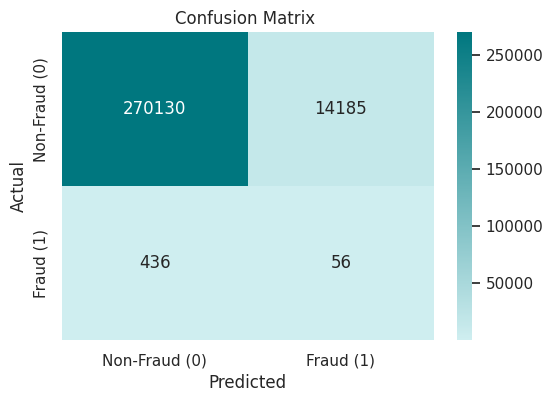

In [16]:
# Plot the confusion matrix
cm = confusion_matrix(y, lof_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

**DBSCAN (Density-Based Clustering)**

- Forms clusters based on density.
- Points that don’t belong to any cluster are treated as noise/outliers.

Trade-off: choosing `eps` and `min_samples` is crucial; wrong values can over/under-flag anomalies.


In [17]:
# Initialize DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit and predict (labels different clusters, outliers labeled as -1)
dbscan_preds = dbscan.fit_predict(X_scaled)

# Convert -1 (anomalies) to 1 (fraud) and others to 0 (non-fraud)
dbscan_preds = [1 if x == -1 else 0 for x in dbscan_preds]

# Evaluate the results
print(classification_report(y, dbscan_preds))
roc_auc = roc_auc_score(y, dbscan_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix:")
print(confusion_matrix(y, dbscan_preds))

              precision    recall  f1-score   support

           0       1.00      0.17      0.28    284315
           1       0.00      0.97      0.00       492

    accuracy                           0.17    284807
   macro avg       0.50      0.57      0.14    284807
weighted avg       1.00      0.17      0.28    284807

ROC AUC Score:  0.568390228746914
Confusion Matrix:
[[ 46979 237336]
 [    14    478]]


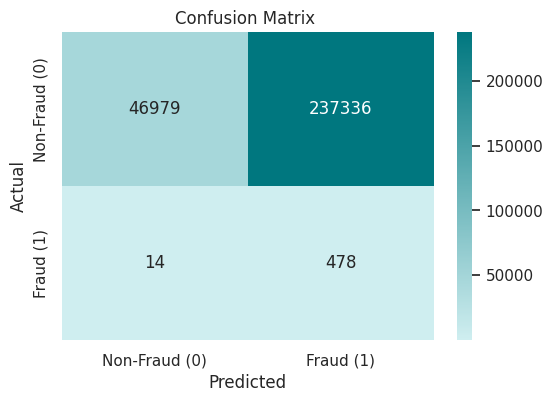

In [18]:
# Plot the confusion matrix
cm = confusion_matrix(y, dbscan_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

**Autoencoders (neural networks)**

- Trained to **reconstruct normal transactions**.
- Transactions with high reconstruction error are flagged as anomalies.

Trade-off: needs more compute + tuning (architecture, threshold, training stability).


In [19]:
# Define the autoencoder model
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    
    # Encoder
    encoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(encoded)
    encoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(encoded)
    
    # Latent space
    latent = Dense(4, activation='relu')(encoded)
    
    # Decoder
    decoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(latent)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(decoded)
    decoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(decoded)
    output_layer = Dense(input_dim, activation='linear')(decoded)
    
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    return autoencoder

# Build and compile the model
autoencoder = build_autoencoder(X_scaled.shape[1])
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse')

# Train the model on normal transactions (non-fraudulent class, y == 0)
X_train = X_scaled[y == 0]
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True, validation_split=0.1)

# Calculate reconstruction error for all transactions
reconstructed = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

# Set a threshold for anomaly detection
threshold = np.percentile(mse, 90)  # Adjust threshold (90th percentile)
autoen_preds = np.where(mse > threshold, 1, 0)  # 1: anomaly (fraud), 0: normal

# Evaluate the model
print(classification_report(y, autoen_preds))
roc_auc = roc_auc_score(y, autoen_preds)
print("ROC AUC Score: ", roc_auc)

Epoch 1/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 1.0080 - val_loss: 0.8775
Epoch 2/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.8797 - val_loss: 0.8417
Epoch 3/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.8570 - val_loss: 0.8155
Epoch 4/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.8272 - val_loss: 0.8027
Epoch 5/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.8111 - val_loss: 0.7886
Epoch 6/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.7979 - val_loss: 0.7767
Epoch 7/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.7906 - val_loss: 0.7584
Epoch 8/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.7795 - val_loss: 0.7468
Epoch 9/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.7731 - val_loss: 0.7370
Epoch 10/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.7673 - val_loss: 0.7267
Epoch 11/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.7592 - val_loss: 0.7166
Epoch 12/50
7997/79

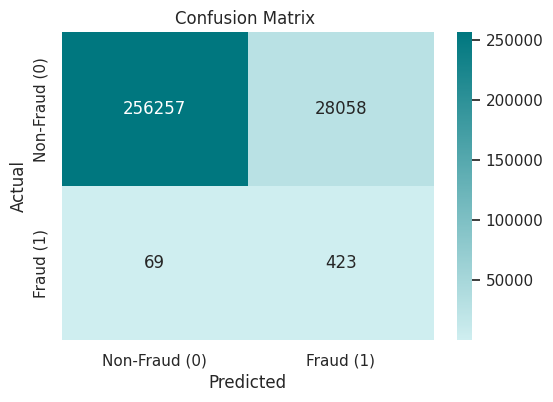

In [20]:
# Plot the confusion matrix
cm = confusion_matrix(y, autoen_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

### What the results suggest

Across models, you’ll usually see this pattern:
- **High recall** for fraud (catching many fraud cases)
- but **low precision** (many normal transactions flagged as fraud)

That happens because fraud is extremely rare, so even a small false-positive rate creates many alerts.

### Practical takeaways
- **DBSCAN** can achieve very high recall but may flag too many normal transactions → often impractical in real systems.
- **Isolation Forest** and **One-Class SVM** often strike a better balance: they catch many fraud cases while reducing false positives compared to very aggressive methods.
- For production, you typically tune:
  - the anomaly threshold / contamination rate,
  - the alerting rules (e.g., alert only above a probability/score cutoff),
  - and measure operational impact (review workload, customer friction, etc.).
